# **Multi-agent System Tutorial**

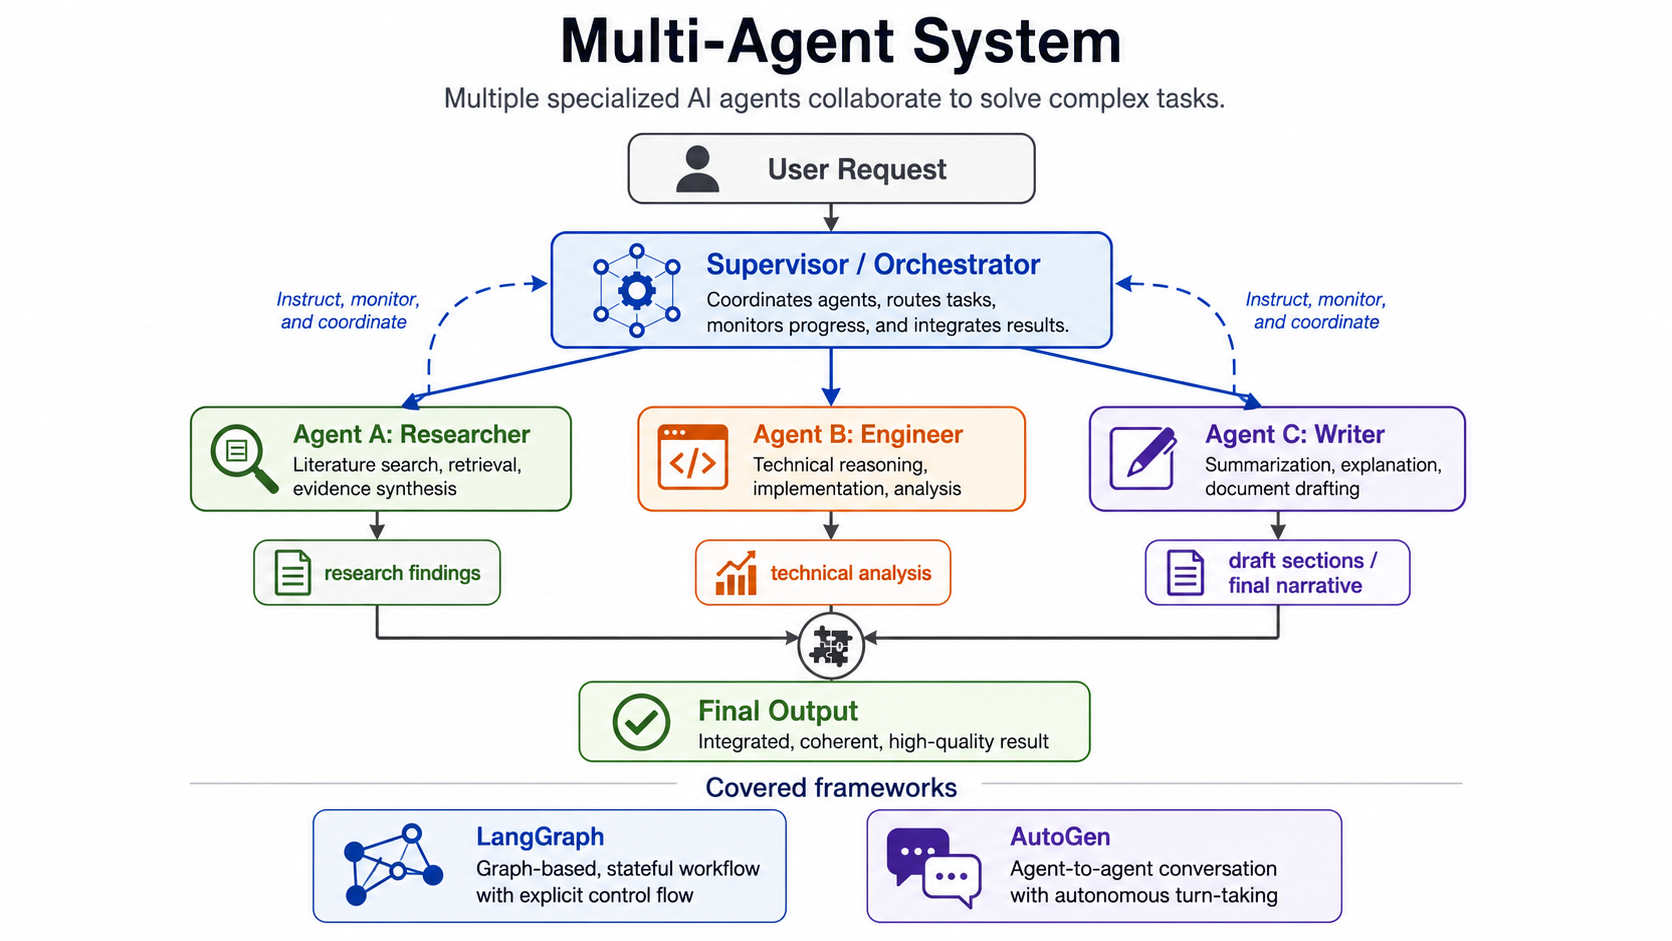

---
# **Part 1: LangGraph**

## **1. Environment Setup**

**1-1. Install packages**

In [ ]:
!pip install langgraph langchain-openai langchain-core -q

**1-2. Set API key**

In [ ]:
import os
os.environ['OPENAI_API_KEY'] = "YOUR API KEY"


## **2. LangGraph Basics**

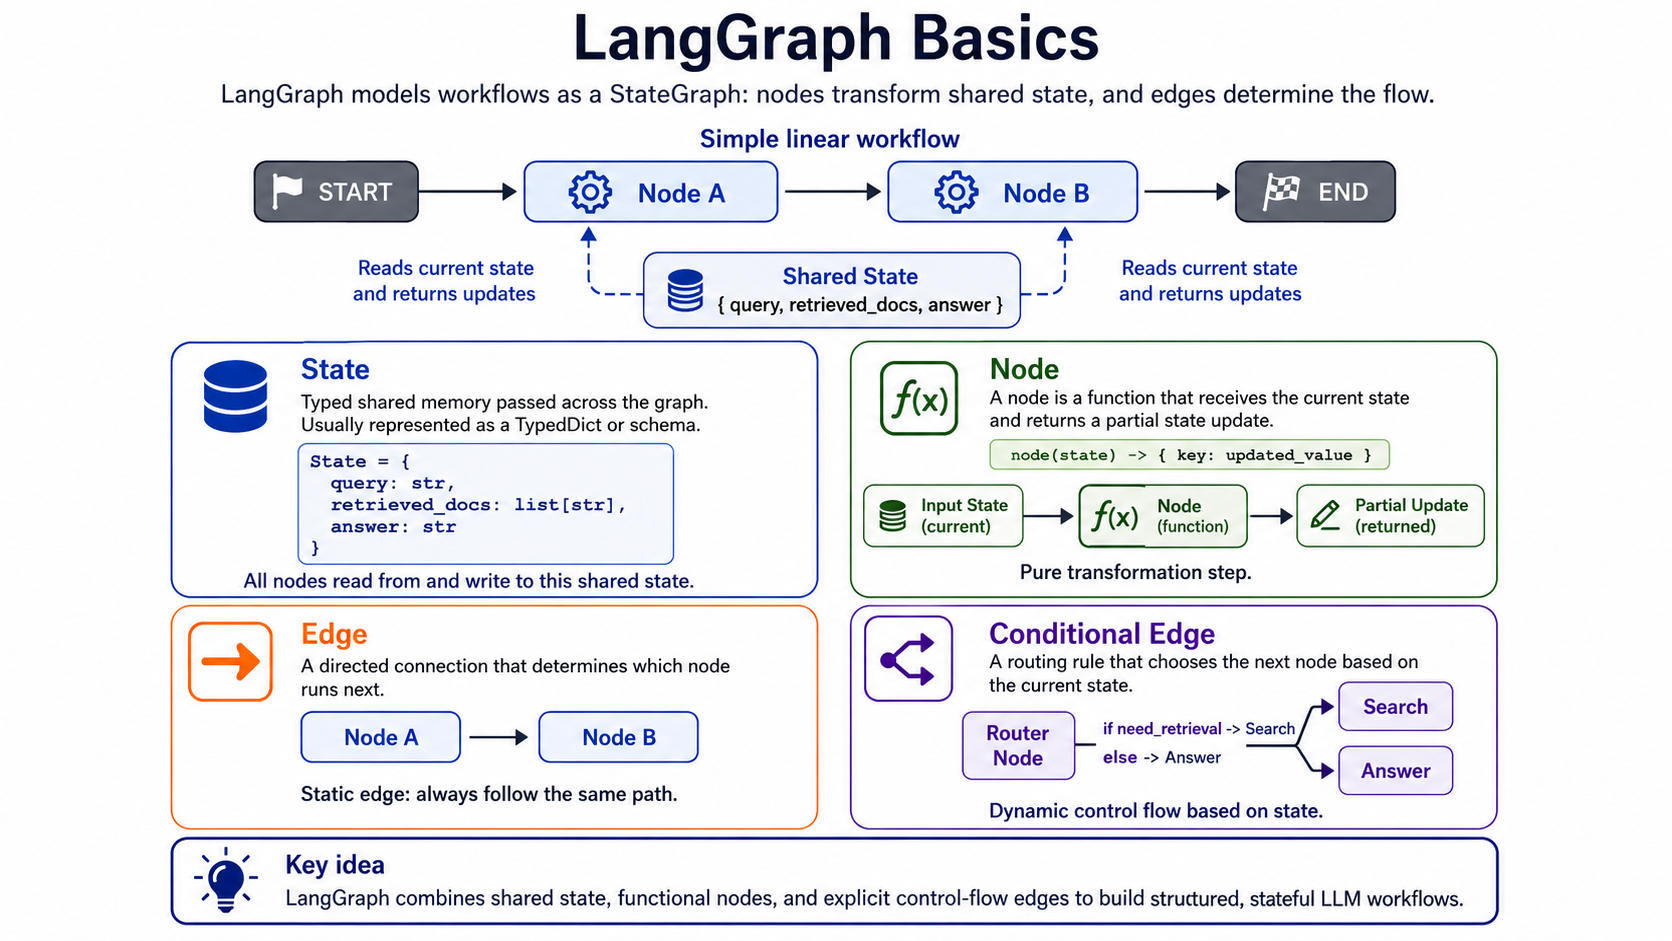

**2-1. Basic StateGraph**

**Step 1 — Define the State**

State is a typed dictionary shared across all nodes. Each node reads from it and returns updates.

In [ ]:
from typing import TypedDict, Annotated
import operator

class PipelineState(TypedDict):
    messages: Annotated[list[str], operator.add]  # operator.add = lists get appended, not overwritten
    step: int

# Test: create a sample state
state = PipelineState(messages=[], step=0)
print(state)


**Step 2 — Define Nodes**

Each node is just a Python function: takes the current state, returns a partial update.

In [ ]:
def data_ingestion(state: PipelineState) -> PipelineState:
    print(f"[Data Ingestion] step={state['step']}")
    return {"messages": ["Sensor data loaded from manufacturing line"], "step": state["step"]+1}

def anomaly_detection(state: PipelineState) -> PipelineState:
    print(f"[Anomaly Detection] step={state['step']}")
    return {"messages": ["PHM model: no anomaly detected (confidence 98.2%)"], "step": state["step"]+1}

def report_generation(state: PipelineState) -> PipelineState:
    print(f"[Report Generation] step={state['step']}")
    summary = " | ".join(state["messages"])
    return {"messages": [f"Report: {summary}"], "step": state["step"]+1}

# Test a single node in isolation
print(data_ingestion({"messages": [], "step": 0}))


**Step 3 — Build the Graph**

Wire nodes together with edges, set the entry point, then compile.

In [ ]:
from langgraph.graph import StateGraph, END

graph = StateGraph(PipelineState)

# Add nodes
graph.add_node("ingest", data_ingestion)
graph.add_node("detect", anomaly_detection)
graph.add_node("report", report_generation)

# Connect with edges
graph.set_entry_point("ingest")
graph.add_edge("ingest", "detect")
graph.add_edge("detect", "report")
graph.add_edge("report", END)

app = graph.compile()
print("Graph compiled!")


**Step 4 — Run the Graph**

In [ ]:
result = app.invoke({"messages": [], "step": 0})

print("\n=== Final State ===")
print(f"Steps executed : {result['step']}")
for msg in result["messages"]:
    print(f"  · {msg}")


In [ ]:
# Visualize the graph structure (ASCII)
print(app.get_graph().draw_ascii())


**2-2. Conditional Edges**

**Step 1 — Define the State**

In [ ]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END

class QualityState(TypedDict):
    product: str
    defect_score: float
    feedback: str
    iterations: int

print(QualityState.__annotations__)


**Step 2 — Define Nodes**

In [ ]:
def inspect_node(state: QualityState) -> QualityState:
    score = min(1.0, len(state["product"]) / 60)
    fb = "Pass" if score >= 0.8 else f"Defect detected — rework required (score={score:.2f})"
    print(f"[Inspection] score={score:.2f}")
    return {"defect_score": score, "feedback": fb}

def rework_node(state: QualityState) -> QualityState:
    improved = state["product"] + " [rework: surface finish corrected, tolerances verified]"
    print(f"[Rework] iteration {state['iterations']+1}")
    return {"product": improved, "iterations": state["iterations"]+1}

def approve_node(state: QualityState) -> QualityState:
    print(f"[Approved] after {state['iterations']} rework(s) — ready for shipment")
    return state

# Test a node
print(inspect_node({"product": "Turbine blade v1", "defect_score": 0.0, "feedback": "", "iterations": 0}))


**Step 3 — Define the Router (conditional edge)**

A router is a function that inspects the state and returns the **name of the next node**.

In [ ]:
def route(state: QualityState) -> Literal["rework", "approve"]:
    if state["defect_score"] < 0.8 and state["iterations"] < 3:
        return "rework"   # loop back
    return "approve"      # exit

# Test the router logic
print(route({"defect_score": 0.5, "iterations": 0, "product": "", "feedback": ""}))  # → rework
print(route({"defect_score": 0.9, "iterations": 0, "product": "", "feedback": ""}))  # → approve


**Step 4 — Build the Graph with Conditional Edges**

In [ ]:
g2 = StateGraph(QualityState)
g2.add_node("inspect", inspect_node)
g2.add_node("rework",  rework_node)
g2.add_node("approve", approve_node)
g2.set_entry_point("inspect")

# Conditional edge: after inspect, call route() to decide next node
g2.add_conditional_edges("inspect", route, {"rework": "rework", "approve": "approve"})
g2.add_edge("rework", "inspect")  # loop back
g2.add_edge("approve", END)

app2 = g2.compile()
print("Graph compiled!")


**Step 5 — Run the Graph**

In [ ]:
r2 = app2.invoke({"product": "Turbine blade v1", "defect_score": 0.0,
                  "feedback": "", "iterations": 0})

print(f"\nFinal product : {r2['product'][:80]}...")
print(f"Final score   : {r2['defect_score']:.2f}")


In [ ]:
# Visualize the conditional graph structure (ASCII)
print(app2.get_graph().draw_ascii())


## **3. Tool-using Agent (ReAct)**

`create_react_agent` implements the **ReAct** loop:

```
Thought → Action (tool call) → Observation → Thought → ... → Final Answer
```


In [ ]:
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import HumanMessage

# ── PRISM-AI domain tools ────────────────────────────────────
@tool
def get_group_info(group_name: str) -> str:
    "Returns research objectives for a PRISM-AI group."
    db = {
        "design": ("Design Group — multi-physics simulation + AI inverse design. "
                   "Target: design accuracy >=95%."),
        "materials": ("Materials Group — PIML/GNN property prediction + LLM recommendation. "
                      "Target: prediction accuracy >=95%."),
        "manufacturing": ("Manufacturing Group — LLM-controlled multi-agent process optimization. "
                          "Target: process control accuracy >=95%."),
        "operations": ("Operations (PHM) Group — LLM-based anomaly explanation + predictive maintenance. "
                       "Target: anomaly detection >=99%."),
        "interface": ("AI Interface Group — natural language platform for non-expert users. "
                      "Target: answer accuracy >=90%."),
    }
    key = group_name.lower().replace(" group", "").strip()
    return db.get(key, f"Group '{group_name}' not found. Available: {list(db.keys())}")

@tool
def get_industry_partner(industry: str) -> str:
    "Returns PRISM-AI industry partners for a given sector."
    db = {
        "automotive":    "Hyundai Motor — process simulation, quality prediction, thermal research.",
        "shipbuilding":  "HD Korea Shipbuilding & Offshore Engineering, Samsung Heavy Industries.",
        "electronics":   "LG Electronics — product design function acquisition.",
        "phm":           "OnePredict (startup, CEO: Prof. Yoon) — PHM algorithms for real plants.",
        "software":      "Nanialabs, Omelet — low-code LLM tools for SME digital transformation.",
    }
    return db.get(industry.lower(), f"No entry for '{industry}'. Available: {list(db.keys())}")

@tool
def calculate_trl_progress(current_trl: int, target_trl: int, years_remaining: int) -> str:
    "Estimates required TRL gain per year to reach target."
    gain = (target_trl - current_trl) / max(years_remaining, 1)
    return (f"To go from TRL {current_trl} to TRL {target_trl} "
            f"in {years_remaining} year(s): need +{gain:.1f} TRL/year.")

llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)
agent = create_react_agent(llm, tools=[get_group_info, get_industry_partner, calculate_trl_progress])

queries = [
    "What does the Operations group aim to achieve?",
    "Who are the shipbuilding partners of PRISM-AI?",
    "PRISM-AI starts at TRL 3 and needs to reach TRL 7 in 5 years. Is that feasible?",
]

for q in queries:
    print(f"Q: {q}")
    result = agent.invoke({"messages": [HumanMessage(content=q)]})
    print(f"A: {result['messages'][-1].content}")
    print("-" * 60)


## **4. Multi-agent: Researcher + Writer Pattern**

Two specialized agents collaborate in sequence.

```
User Topic
    │
    ▼
[Researcher] ── findings ──▶ [Writer] ── article ──▶ END
```


In [ ]:
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
import operator

class ColabState(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]
    topic: str
    research: str
    article: str

llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0.7)

def researcher_node(state: ColabState) -> ColabState:
    print("\n[Researcher] investigating...")
    prompt = (
        "You are a technical researcher specializing in AI for manufacturing.\n"
        f"Topic: {state['topic']}\n\n"
        "Summarize: 2-3 key concepts, main challenges, and 1-2 real-world applications. "
        "Keep it under 250 words."
    )
    resp = llm.invoke([HumanMessage(content=prompt)])
    print(f"[Researcher] done ({len(resp.content)} chars)")
    return {
        "messages": [AIMessage(content=f"[RESEARCH]\n{resp.content}")],
        "research": resp.content
    }

def writer_node(state: ColabState) -> ColabState:
    print("\n[Writer] drafting article...")
    prompt = (
        "You are a science communicator writing for an engineering audience.\n"
        f"Topic: {state['topic']}\n\n"
        f"Research notes:\n{state['research']}\n\n"
        "Write a clear, engaging article (~300 words). End with a one-sentence takeaway."
    )
    resp = llm.invoke([HumanMessage(content=prompt)])
    print(f"[Writer] done ({len(resp.content)} chars)")
    return {
        "messages": [AIMessage(content=f"[ARTICLE]\n{resp.content}")],
        "article": resp.content
    }

g3 = StateGraph(ColabState)
g3.add_node("researcher", researcher_node)
g3.add_node("writer", writer_node)
g3.set_entry_point("researcher")
g3.add_edge("researcher", "writer")
g3.add_edge("writer", END)
collab_app = g3.compile()


In [ ]:
topic = "RAG-based knowledge retrieval in PRISM-AI's manufacturing AI platform"
print(f"Topic: {topic}\n" + "="*60)

result = collab_app.invoke({
    "messages": [HumanMessage(content=topic)],
    "topic": topic, "research": "", "article": ""
})

print("\n" + "="*60)
print("=== Final Article ===")
print(result["article"])


## **5. Supervisor Pattern (Advanced)**

A Supervisor agent routes tasks to specialized workers and decides when the job is done.

```
User Request ──▶ [Supervisor]
                     │
          ┌──────────┼──────────┐
          ▼          ▼          ▼
    [Researcher]  [Engineer]  [Analyst]
          └──────────┴──────────┘
                     │ results
                     ▼
              [Supervisor] → FINISH
```


In [ ]:
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
import operator

WORKERS = ["researcher", "engineer", "analyst"]

class SupervState(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]
    next: str

llm_s = ChatOpenAI(model="gpt-5.4-mini", temperature=0)

def supervisor(state: SupervState) -> SupervState:
    sys_msg = (
        "You are a project supervisor for PRISM-AI. Reply with EXACTLY one word:\n"
        "- researcher : needs domain knowledge or literature\n"
        "- engineer   : needs technical design or code\n"
        "- analyst    : needs data analysis or comparison\n"
        "- FINISH     : task is complete\n"
        "Decide based on the conversation so far."
    )
    msgs = [SystemMessage(content=sys_msg)] + state["messages"]
    resp = llm_s.invoke(msgs)
    decision = resp.content.strip().lower()
    if decision not in WORKERS:
        decision = "FINISH"
    print(f"\n[Supervisor] → {decision}")
    return {"messages": [AIMessage(content=f"[Supervisor → {decision}]")], "next": decision}

def make_worker(name, role):
    def node(state: SupervState) -> SupervState:
        print(f"[{name.capitalize()}] working...")
        last = next((m.content for m in reversed(state["messages"])
                     if isinstance(m, HumanMessage)), "proceed")
        resp = llm_s.invoke([HumanMessage(
            content=f"You are a {role}. Address this task concisely: {last}"
        )])
        return {"messages": [AIMessage(content=f"[{name.upper()}]\n{resp.content}")]}
    node.__name__ = f"{name}_node"
    return node

researcher2 = make_worker("researcher", "AI manufacturing research expert")
engineer2   = make_worker("engineer",   "senior software engineer specializing in LLM systems")
analyst2    = make_worker("analyst",    "data analyst for manufacturing KPIs")

def route(state: SupervState) -> str:
    return "__end__" if state.get("next") == "FINISH" else state.get("next", "__end__")

g4 = StateGraph(SupervState)
g4.add_node("supervisor", supervisor)
g4.add_node("researcher", researcher2)
g4.add_node("engineer",   engineer2)
g4.add_node("analyst",    analyst2)
g4.set_entry_point("supervisor")
g4.add_conditional_edges(
    "supervisor", route,
    {"researcher": "researcher", "engineer": "engineer",
     "analyst": "analyst", "__end__": END}
)
for w in WORKERS:
    g4.add_edge(w, "supervisor")   # every worker reports back to supervisor

sup_app = g4.compile()


In [ ]:
task = (
    "How should PRISM-AI implement a RAG system for its Manufacturing Group "
    "so that engineers can query process parameters using natural language?"
)
print(f"Task: {task}\n" + "="*60)

result = sup_app.invoke(
    {"messages": [HumanMessage(content=task)], "next": ""},
    {"recursion_limit": 8}
)

print("\n" + "="*60)
print("=== Full conversation log ===")
for msg in result["messages"]:
    if isinstance(msg, AIMessage):
        print(f"\n{msg.content[:300]}...")


---
# **Part 2: AutoGen**

**AutoGen** (Microsoft) enables autonomous agent conversation to collaboratively solve tasks.

**LangGraph vs AutoGen at a glance:**

| | LangGraph | AutoGen |
|-|-----------|---------|
| Control | Explicit graph + state | Autonomous turn-taking |
| Best for | Deterministic pipelines | Exploratory, open-ended tasks |
| Learning curve | Medium | Low |
| Debuggability | High (state inspection) | Medium |


## **6. Environment Setup (AutoGen)**

In [ ]:
!pip install autogen-agentchat autogen-ext[openai] nest_asyncio -q

In [ ]:
import os, asyncio
import nest_asyncio
nest_asyncio.apply()   # needed for asyncio.run() inside Colab

from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.conditions import MaxMessageTermination, TextMentionTermination
from autogen_agentchat.teams import RoundRobinGroupChat, SelectorGroupChat
from autogen_agentchat.ui import Console
from autogen_ext.models.openai import OpenAIChatCompletionClient

model_client = OpenAIChatCompletionClient(
    model="gpt-5.4-mini",
    api_key=os.environ.get("OPENAI_API_KEY")
)
print("AutoGen ready!")


## **7. Two-Agent Conversation (RoundRobinGroupChat)**

In [ ]:
researcher_ag = AssistantAgent(
    name="Researcher",
    model_client=model_client,
    system_message=(
        "You are a technical researcher specializing in AI for smart manufacturing.\n"
        "Investigate the given topic and summarize 3-4 key technical points.\n"
        "Then hand over to the Writer."
    ),
)

writer_ag = AssistantAgent(
    name="Writer",
    model_client=model_client,
    system_message=(
        "You are a science communicator writing for engineers.\n"
        "Based on the Researcher's notes, write a concise, clear article.\n"
        "End your response with TERMINATE."
    ),
)

termination = TextMentionTermination("TERMINATE") | MaxMessageTermination(6)
team = RoundRobinGroupChat([researcher_ag, writer_ag], termination_condition=termination)

async def run_team():
    task = (
        "Explain how LLM-based multi-agent systems like PRISM-AI "
        "can automate the full manufacturing pipeline from design to operations."
    )
    print(f"Task: {task}\n" + "="*60)
    await Console(team.run_stream(task=task))

asyncio.run(run_team())


**Reset and run again with a different topic:**

In [ ]:
async def run_again():
    await team.reset()
    task = (
        "Compare RAG and fine-tuning for building domain-specific "
        "question-answering systems in manufacturing AI."
    )
    print(f"Task: {task}\n" + "="*60)
    await Console(team.run_stream(task=task))

asyncio.run(run_again())


## **8. SelectorGroupChat — Dynamic Speaker Selection**

The LLM decides at each turn who should speak next based on conversation context.

```
User Request
     │
     ▼
[SelectorGroupChat]
  LLM judges: who should respond?
  ↓                 ↓                ↓
[PI/PM]       [ML Engineer]   [PHM Specialist]
```


In [ ]:
pi_agent = AssistantAgent(
    name="PI_ProjectManager",
    model_client=model_client,
    system_message=(
        "You are a principal investigator / project manager for PRISM-AI.\n"
        "You handle strategic planning, timelines, and resource allocation."
    ),
)

ml_engineer = AssistantAgent(
    name="ML_Engineer",
    model_client=model_client,
    system_message=(
        "You are a senior ML engineer at PRISM-AI.\n"
        "You specialize in LLM integration, RAG pipelines, and multi-agent architectures."
    ),
)

phm_specialist = AssistantAgent(
    name="PHM_Specialist",
    model_client=model_client,
    system_message=(
        "You are a PHM (Prognostics and Health Management) specialist.\n"
        "You focus on anomaly detection, predictive maintenance, and sensor data pipelines."
    ),
)

selector_team = SelectorGroupChat(
    [pi_agent, ml_engineer, phm_specialist],
    model_client=model_client,
    termination_condition=MaxMessageTermination(8),
)

async def run_selector():
    task = (
        "PRISM-AI needs to deploy a real-time anomaly detection system "
        "for a shipbuilding production line within 3 months. "
        "How should the team approach this challenge?"
    )
    print(f"Task: {task}\n" + "="*60)
    await Console(selector_team.run_stream(task=task))

asyncio.run(run_selector())


## **9. Agents with Tools**

In [ ]:
import datetime

def get_prism_ai_status(group: str) -> str:
    "Returns current TRL and milestone status for a PRISM-AI research group."
    status = {
        "design":        "TRL 3 → target TRL 7. Milestone 2025: surrogate model prototype.",
        "materials":     "TRL 3 → target TRL 7. Milestone 2025: PIML property prediction demo.",
        "manufacturing": "TRL 2 → target TRL 7. Milestone 2025: LLM-to-equipment control demo.",
        "operations":    "TRL 4 → target TRL 7. Milestone 2025: PHM anomaly detection >=99%.",
        "interface":     "TRL 2 → target TRL 7. Milestone 2026: natural language platform beta.",
    }
    return status.get(group.lower(), f"Unknown group: {group}")

def days_until(date_str: str) -> str:
    "Returns days until a target date (YYYY-MM-DD)."
    try:
        target = datetime.datetime.strptime(date_str, "%Y-%m-%d")
        delta = (target - datetime.datetime.now()).days
        return f"{date_str}: {delta} days from today." if delta >= 0 else f"{date_str} was {-delta} days ago."
    except ValueError:
        return "Invalid date format (use YYYY-MM-DD)."

def get_prism_ai_kpi() -> str:
    "Returns key performance indicators for the PRISM-AI project."
    return (
        "PRISM-AI KPIs (5-year targets):\n"
        "· SCI papers  : 300+\n"
        "· Patents      : 20+\n"
        "· Postdocs trained : 250 (50/year)\n"
        "· Industry demos   : 30+ cases\n"
        "· TRL at end       : 7 (full-cycle platform)\n"
        "· Design accuracy  : >=95%\n"
        "· PHM accuracy     : >=99%\n"
        "· NL interface acc : >=90%"
    )

status_agent = AssistantAgent(
    name="PRISMStatusAgent",
    model_client=model_client,
    tools=[get_prism_ai_status, days_until, get_prism_ai_kpi],
    system_message=(
        "You are the PRISM-AI project status assistant.\n"
        "Use tools to retrieve accurate project information.\n"
        "After answering, end with TERMINATE."
    ),
)

status_team = RoundRobinGroupChat(
    [status_agent],
    termination_condition=TextMentionTermination("TERMINATE") | MaxMessageTermination(4),
)

async def run_status():
    task = (
        "What is the current TRL status of each PRISM-AI group? "
        "How many days until the Year 2 milestone on 2026-12-31? "
        "Also summarize the 5-year KPI targets."
    )
    print(f"Task: {task}\n" + "="*60)
    await Console(status_team.run_stream(task=task))

asyncio.run(run_status())
